<a href="https://colab.research.google.com/github/baanujan-18/PLC---Automation/blob/main/plc-occupancy-controlled-fan-system/colab/occupancy-fan-control-verification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PLC-Based Occupancy-Controlled Fan System

This notebook generates a documentation ladder diagram for an occupancy-controlled three-fan system.

- S1 / I0.0: Entry count
- S2 / I0.1: Exit count
- Q0.0: Fan 1
- Q0.1: Fan 2
- Q0.2: Fan 3

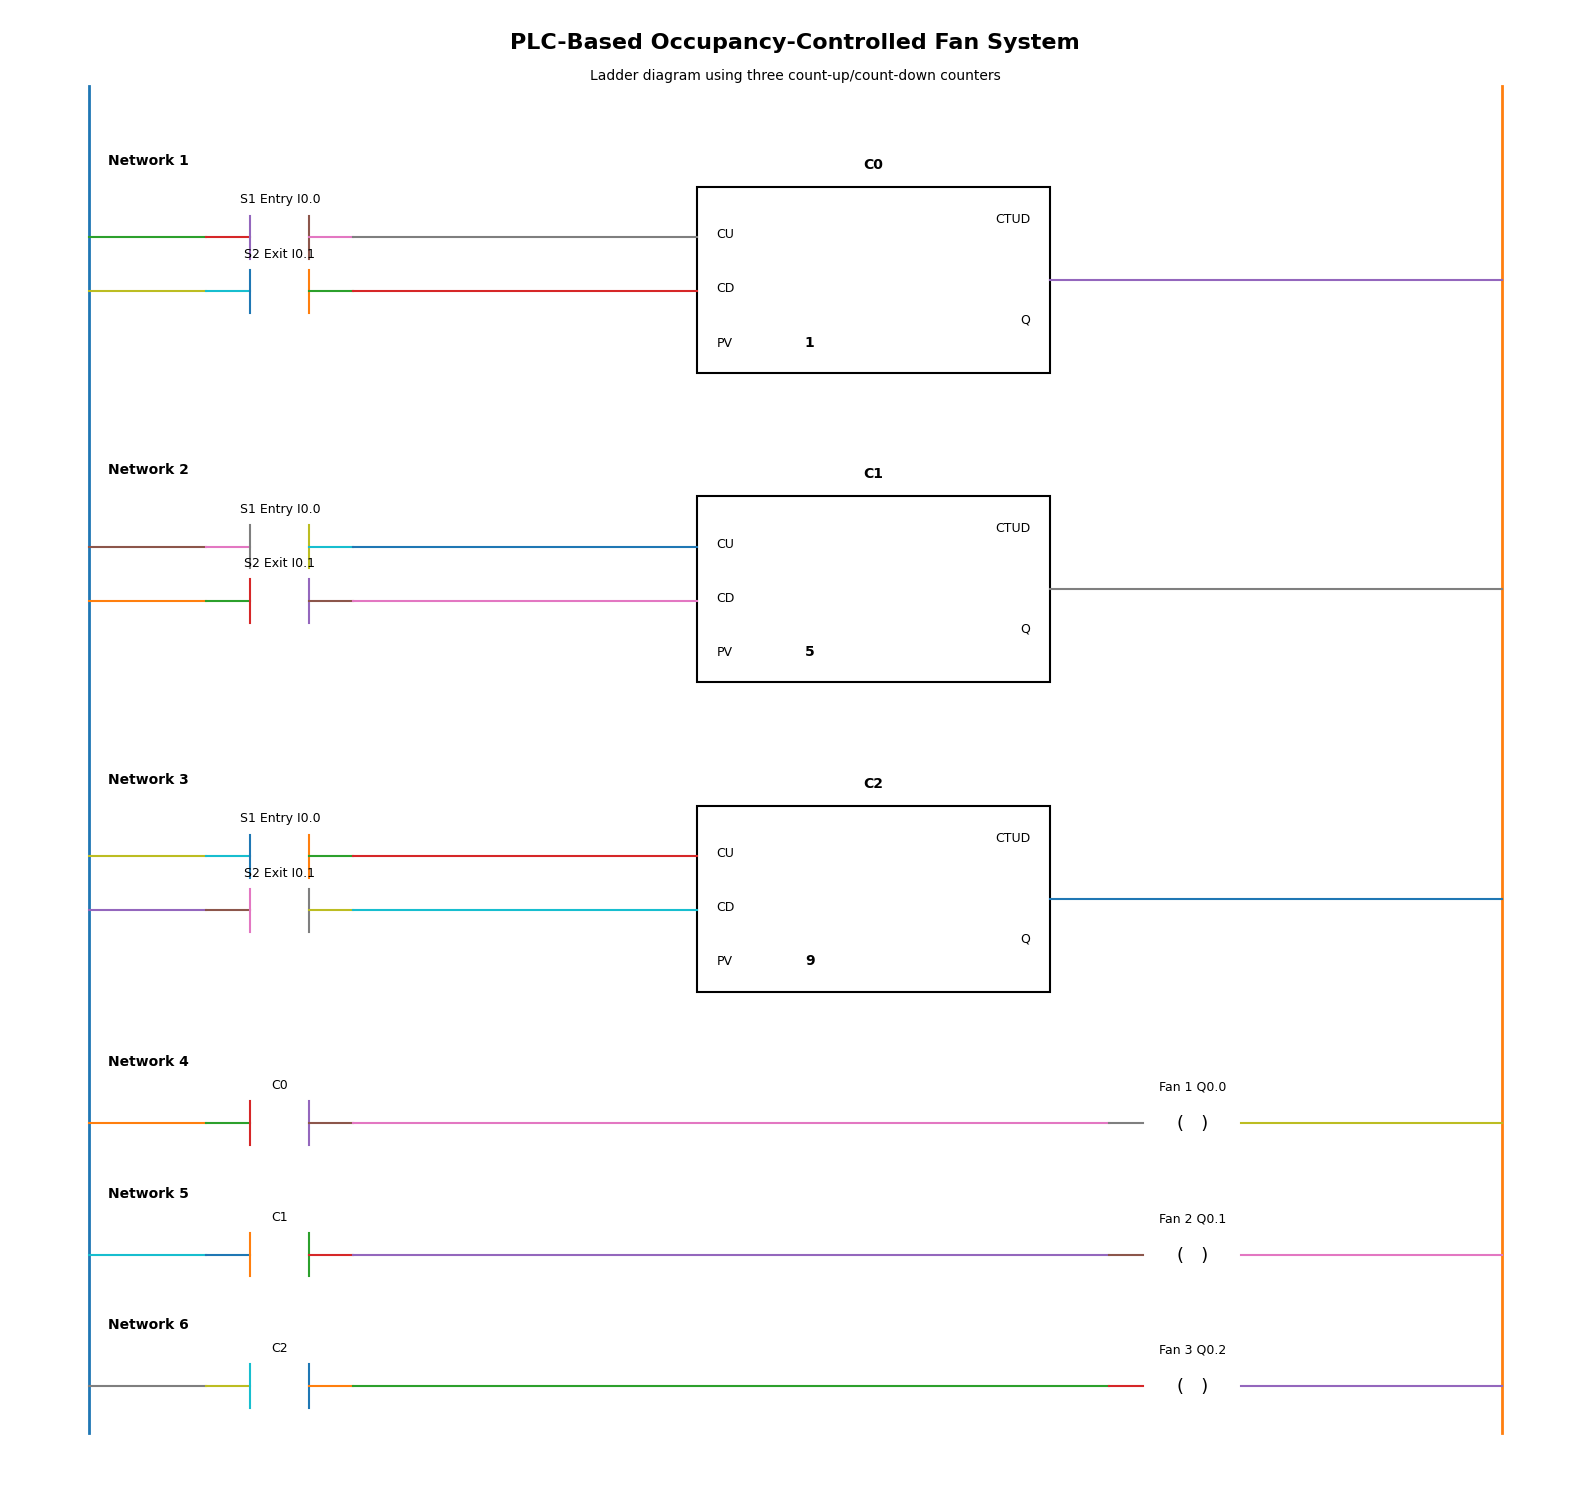

Created:
occupancy_fan_control_ladder.png
occupancy_fan_control_ladder.pdf


In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------------------------------------------------------
# Figure setup
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 15))

ax.set_xlim(0, 16)
ax.set_ylim(0, 19)
ax.axis("off")

LEFT_RAIL = 0.8
RIGHT_RAIL = 15.2

# Main ladder rails
ax.plot([LEFT_RAIL, LEFT_RAIL], [0.6, 18], linewidth=2)
ax.plot([RIGHT_RAIL, RIGHT_RAIL], [0.6, 18], linewidth=2)


# ---------------------------------------------------------
# Drawing functions
# ---------------------------------------------------------

def wire(x1, x2, y):
    ax.plot([x1, x2], [y, y], linewidth=1.5)


def contact(x, y, label):
    """Draw a normally open contact."""

    wire(x, x + 0.45, y)

    ax.plot(
        [x + 0.45, x + 0.45],
        [y - 0.28, y + 0.28],
        linewidth=1.5
    )

    ax.plot(
        [x + 1.05, x + 1.05],
        [y - 0.28, y + 0.28],
        linewidth=1.5
    )

    wire(x + 1.05, x + 1.5, y)

    ax.text(
        x + 0.75,
        y + 0.45,
        label,
        ha="center",
        fontsize=9
    )

    return x + 1.5


def coil(x, y, label):
    """Draw a standard output coil."""

    wire(x, x + 0.35, y)

    ax.text(
        x + 0.85,
        y,
        "(   )",
        ha="center",
        va="center",
        fontsize=13
    )

    ax.text(
        x + 0.85,
        y + 0.43,
        label,
        ha="center",
        fontsize=9
    )

    wire(x + 1.35, RIGHT_RAIL, y)


def ctud_block(x, y, counter_name, preset):
    """Draw a count-up/count-down counter block."""

    width = 3.6
    height = 2.4

    block = Rectangle(
        (x, y - height / 2),
        width,
        height,
        fill=False,
        linewidth=1.5
    )

    ax.add_patch(block)

    # Counter name
    ax.text(
        x + width / 2,
        y + 1.45,
        counter_name,
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

    # Function name
    ax.text(
        x + width - 0.2,
        y + 0.75,
        "CTUD",
        ha="right",
        fontsize=9
    )

    # Input labels
    ax.text(x + 0.2, y + 0.55, "CU", fontsize=9)
    ax.text(x + 0.2, y - 0.15, "CD", fontsize=9)
    ax.text(x + 0.2, y - 0.85, "PV", fontsize=9)

    # Preset value
    ax.text(
        x + 1.1,
        y - 0.85,
        str(preset),
        fontsize=10,
        fontweight="bold"
    )

    # Counter output label
    ax.text(
        x + width - 0.2,
        y - 0.55,
        "Q",
        ha="right",
        fontsize=9
    )

    return x + width


def draw_counter_network(network_number, y, counter_name, preset):
    """Draw one CTUD network."""

    ax.text(
        1.0,
        y + 1.5,
        f"Network {network_number}",
        fontsize=10,
        fontweight="bold"
    )

    # Entry input connected to CU
    wire(LEFT_RAIL, 2.0, y + 0.55)

    entry_end = contact(
        2.0,
        y + 0.55,
        "S1 Entry I0.0"
    )

    wire(entry_end, 7.0, y + 0.55)

    # Exit input connected to CD
    wire(LEFT_RAIL, 2.0, y - 0.15)

    exit_end = contact(
        2.0,
        y - 0.15,
        "S2 Exit I0.1"
    )

    wire(exit_end, 7.0, y - 0.15)

    # Counter block
    counter_end = ctud_block(
        7.0,
        y,
        counter_name,
        preset
    )

    wire(counter_end, RIGHT_RAIL, y)


# ---------------------------------------------------------
# Counter networks
# ---------------------------------------------------------

# Fan 1 becomes active from one person
draw_counter_network(
    network_number=1,
    y=15.5,
    counter_name="C0",
    preset=1
)

# Fan 2 becomes active from five people
draw_counter_network(
    network_number=2,
    y=11.5,
    counter_name="C1",
    preset=5
)

# Fan 3 becomes active from nine people
draw_counter_network(
    network_number=3,
    y=7.5,
    counter_name="C2",
    preset=9
)


# ---------------------------------------------------------
# Output networks
# ---------------------------------------------------------

# Network 4: C0 controls Fan 1
y = 4.6

ax.text(
    1.0,
    y + 0.75,
    "Network 4",
    fontsize=10,
    fontweight="bold"
)

wire(LEFT_RAIL, 2.0, y)
end_contact = contact(2.0, y, "C0")
wire(end_contact, 11.2, y)
coil(11.2, y, "Fan 1 Q0.0")


# Network 5: C1 controls Fan 2
y = 2.9

ax.text(
    1.0,
    y + 0.75,
    "Network 5",
    fontsize=10,
    fontweight="bold"
)

wire(LEFT_RAIL, 2.0, y)
end_contact = contact(2.0, y, "C1")
wire(end_contact, 11.2, y)
coil(11.2, y, "Fan 2 Q0.1")


# Network 6: C2 controls Fan 3
y = 1.2

ax.text(
    1.0,
    y + 0.75,
    "Network 6",
    fontsize=10,
    fontweight="bold"
)

wire(LEFT_RAIL, 2.0, y)
end_contact = contact(2.0, y, "C2")
wire(end_contact, 11.2, y)
coil(11.2, y, "Fan 3 Q0.2")


# ---------------------------------------------------------
# Title and export
# ---------------------------------------------------------

ax.text(
    8.0,
    18.5,
    "PLC-Based Occupancy-Controlled Fan System",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    8.0,
    18.1,
    "Ladder diagram using three count-up/count-down counters",
    ha="center",
    fontsize=10
)

plt.tight_layout()

# Save as PNG image
plt.savefig(
    "occupancy_fan_control_ladder.png",
    dpi=300,
    bbox_inches="tight"
)

# Save as PDF
plt.savefig(
    "occupancy_fan_control_ladder.pdf",
    bbox_inches="tight"
)

plt.show()

print("Created:")
print("occupancy_fan_control_ladder.png")
print("occupancy_fan_control_ladder.pdf")

In [2]:
from google.colab import files

files.download("occupancy_fan_control_ladder.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
from google.colab import files

files.download("occupancy_fan_control_ladder.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>